<a href="https://colab.research.google.com/github/ayualfia/PBA-Amazon-SentimentAnalysis/blob/main/week2_amazon_shopping_reviews_scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scraping Review Aplikasi Amazon Shopping

## Aplikasi yang Di-Scraping
- **Nama Aplikasi:** Amazon Shopping
- **Link Google Play:** https://play.google.com/store/apps/details?id=com.amazon.mShop.android.shopping&hl=id
- **ID Aplikasi:** com.amazon.mShop.android.shopping

## Tujuan
Mengambil data review dari aplikasi Amazon Shopping di Google Play Store, mengubahnya ke dalam bentuk dataset, menyimpan hasilnya ke file CSV/XLSX, dan menampilkan distribusi rating dalam bentuk histogram.

## Deskripsi Proses
1. **Scraping Review**
   - Mengambil data ulasan pengguna dari Google Play Store menggunakan library `google_play_scraper`.
   - Review diambil berdasarkan urutan terbaru.

2. **Pembentukan Dataset**
   - Data hasil scraping diubah ke dalam bentuk DataFrame menggunakan `pandas`.
   - Dataset kemudian disimpan ke format CSV.

3. **Visualisasi Data**
   - Data rating (`score`) digunakan untuk melihat distribusi penilaian pengguna.
   - Distribusi rating divisualisasikan menggunakan histogram.

## Output
- Dataset review dalam format **CSV**
- Histogram distribusi rating review

## Informasi Dataset
Dataset berisi ulasan pengguna aplikasi Amazon Shopping dari Google Play Store. Beberapa kolom penting yang digunakan dalam dataset antara lain:
- `reviewId`: ID unik review
- `userName`: nama pengguna
- `content`: isi review
- `score`: rating bintang (1–5)
- `thumbsUpCount`: jumlah likes pada review
- `at`: tanggal review dibuat
- `replyContent`: balasan dari developer
- `repliedAt`: tanggal balasan developer


## amazon-shopping-reviews-scrapping

In [1]:
# 01-amazon-shopping-reviews-scrapping.ipynb
# Tujuan: Mengambil review aplikasi Amazon Shopping dari Google Play Store, memfilter review berbahasa Inggris, dan menyimpan ke CSV.
# Catatan: Filtering bahasa Inggris dilakukan untuk memastikan analisis sentimen dan preprocessing teks lebih akurat,
# karena model NLP yang digunakan pada tahap berikutnya dioptimalkan untuk bahasa Inggris.

# Instalasi library yang diperlukan
try:
    import google_play_scraper
except ImportError:
    !pip install google_play_scraper

try:
    import langdetect
except ImportError:
    !pip install langdetect

try:
    import tqdm
except ImportError:
    !pip install tqdm

try:
    import matplotlib
except ImportError:
    !pip install matplotlib

# Impor library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google_play_scraper import reviews_all, Sort
from langdetect import detect, LangDetectException
from tqdm import tqdm
import os
import time

# Mengambil semua review dari aplikasi Amazon Shopping
try:
    start_time = time.time()
    amazon_reviews = reviews_all(
        'com.amazon.mShop.android.shopping',  # ID aplikasi Amazon Shopping
        sleep_milliseconds=100,  # Jeda 100ms untuk keamanan
        lang='en',  # Bahasa Inggris (preferensi)
        sort=Sort.NEWEST  # Urutkan berdasarkan yang terbaru
    )
    print(f"Waktu scraping: {time.time() - start_time:.2f} detik")
except Exception as e:
    print(f"Error saat scraping: {e}")
    amazon_reviews = []

# Konversi hasil scraping ke DataFrame
if not amazon_reviews:
    print("Tidak ada review yang berhasil di-scraping.")
else:
    df_amazon_reviews = pd.DataFrame(np.array(amazon_reviews), columns=['content'])
    df_amazon_reviews = df_amazon_reviews.join(pd.DataFrame(df_amazon_reviews.pop('content').tolist()))

    # Menampilkan jumlah total review yang di-scraping
    print(f"Jumlah total data yang di-scraping: {df_amazon_reviews.shape[0]}")

    # Fungsi untuk mendeteksi bahasa
    def detect_language(text):
        try:
            return detect(text)
        except LangDetectException:
            common_english_words = {'good', 'great', 'bad', 'love', 'hate', 'app', 'amazon', 'shopping', 'awesome'}
            if any(word in text.lower() for word in common_english_words):
                return 'en'
            return 'unknown'

    # Pastikan kolom 'content' tidak memiliki NaN dan dikonversi ke string
    df_amazon_reviews['content'] = df_amazon_reviews['content'].astype(str).fillna("")

    # Hapus review kosong
    initial_count = df_amazon_reviews.shape[0]
    df_amazon_reviews = df_amazon_reviews[df_amazon_reviews['content'].str.strip() != ""]
    empty_count = initial_count - df_amazon_reviews.shape[0]
    print(f"Jumlah review kosong yang dihapus: {empty_count}")

    # Tambahkan kolom bahasa dengan progress bar
    tqdm.pandas()
    df_amazon_reviews['language'] = df_amazon_reviews['content'].progress_apply(detect_language)

    # Hitung review non-Inggris
    non_english_count = df_amazon_reviews[df_amazon_reviews['language'] != 'en'].shape[0]
    print(f"Jumlah review non-Inggris yang dihapus: {non_english_count}")

    # Filter hanya review berbahasa Inggris
    df_amazon_reviews = df_amazon_reviews[df_amazon_reviews['language'] == 'en']

    # Hapus kolom 'language' setelah filtering
    df_amazon_reviews = df_amazon_reviews.drop(columns=['language'])

    # Menampilkan jumlah review berbahasa Inggris
    print(f"Jumlah review berbahasa Inggris: {df_amazon_reviews.shape[0]}")

    # Menampilkan 5 baris pertama dari DataFrame
    print("\nContoh 5 baris pertama dari data (bahasa Inggris):")
    display(df_amazon_reviews.head())

    # Menampilkan sampel acak
    print("\nSampel acak 10 review berbahasa Inggris:")
    display(df_amazon_reviews[['content', 'score']].sample(min(10, len(df_amazon_reviews))))

    # Menampilkan statistik dasar
    print("\nStatistik Dasar Data:")
    print(f"Kolom yang di-scraping: {df_amazon_reviews.columns.tolist()}")
    print(f"Rentang tanggal review: {df_amazon_reviews['at'].min()} hingga {df_amazon_reviews['at'].max()}")
    print("\nDistribusi Skor Review:")
    print(df_amazon_reviews['score'].value_counts().sort_index())

    # Menyimpan DataFrame ke file CSV
    file_path = 'amazon_reviews.csv'
    if os.path.exists(file_path):
        print(f"File {file_path} sudah ada. Tidak akan ditimpa.")
    else:
        df_amazon_reviews.to_csv(file_path, index=False, encoding='utf-8')
        print(f"DataFrame telah disimpan ke {file_path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 46.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b28c71baf4a7cf2b307ce7cbd401c44ffd6c212427060e04bc1051c67537cd91
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
Waktu scraping: 193.33 detik
Jumlah total data yang di-scraping: 440557
Jumlah review kosong yang dihapus: 0


100%|██████████| 440557/440557 [31:46<00:00, 231.07it/s]


Jumlah review non-Inggris yang dihapus: 105756
Jumlah review berbahasa Inggris: 334801

Contoh 5 baris pertama dari data (bahasa Inggris):


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,None,NaT,32.5.0.100
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,None,NaT,32.5.0.100
4,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,None,NaT,32.5.0.100
9,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,None,NaT,32.5.0.100
10,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,GOOD 🥰🥰🥰 service,5,0,None,2026-03-09 17:32:49,None,NaT,None



Sampel acak 10 review berbahasa Inggris:


,content,score
135070,Working on time,5
45458,Can't find in store code in the new version of...,1
409239,It is too nice. Ghar bathe shopping ka maza,5
27173,today I got the worst service I've ever gotten...,1
20259,I love all of us,5
129661,The delivery driver literally stole my package...,1
401107,"It's an very good app, I love Amazon it works ...",5
336626,I have two Amazon accounts (one is for my busi...,2
43768,easy photo shop its useful,5
295844,Boo. Let me go to the website instead of makin...,1



Statistik Dasar Data:
Kolom yang di-scraping: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']
Rentang tanggal review: 2014-12-11 03:18:23 hingga 2026-03-09 18:57:26

Distribusi Skor Review:
score
1    107683
2     23947
3     21439
4     25867
5    155865
Name: count, dtype: int64
DataFrame telah disimpan ke amazon_reviews.csv


In [2]:
print(f"Jumlah data yang telah di-scraping: {df_amazon_reviews.shape[0]}")

Jumlah data yang telah di-scraping: 334801


In [3]:
print("Informasi DataFrame:")
df_amazon_reviews.info()

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 334801 entries, 0 to 440556
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              334801 non-null  object        
 1   userName              334801 non-null  object        
 2   userImage             334801 non-null  object        
 3   content               334801 non-null  object        
 4   score                 334801 non-null  int64         
 5   thumbsUpCount         334801 non-null  int64         
 6   reviewCreatedVersion  269543 non-null  object        
 7   at                    334801 non-null  datetime64[ns]
 8   replyContent          55 non-null      object        
 9   repliedAt             55 non-null      datetime64[ns]
 10  appVersion            269543 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 30.7+ MB


In [4]:
from google.colab import files
files.download('amazon_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## amazon-shopping-reviews-exploratory-data-analysis

In [9]:
# Instalasi library yang diperlukan
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from wordcloud import WordCloud
    from collections import Counter
    import nltk
except ImportError:
    !pip install pandas numpy matplotlib seaborn wordcloud nltk

# Download resource NLTK untuk tokenisasi
nltk.download('punkt', quiet=True)

# Impor library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
import os

In [10]:
# Mengatur gaya visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# Membaca data dari file CSV
file_path = 'amazon_reviews.csv'

if not os.path.exists(file_path):
    print(f"File {file_path} tidak ditemukan. Pastikan file ada di direktori yang sama.")
else:
    df_reviews = pd.read_csv(file_path)
    print(f"File {file_path} berhasil dibaca.")

File amazon_reviews.csv berhasil dibaca.


/tmp/ipykernel_239/2313850921.py:7: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.read_csv(file_path)


In [14]:
# Menampilkan informasi dasar DataFrame
print("Informasi DataFrame:")
df_reviews.info()

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334801 entries, 0 to 334800
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              334801 non-null  object
 1   userName              334801 non-null  object
 2   userImage             334801 non-null  object
 3   content               334801 non-null  object
 4   score                 334801 non-null  int64 
 5   thumbsUpCount         334801 non-null  int64 
 6   reviewCreatedVersion  269543 non-null  object
 7   at                    334801 non-null  object
 8   replyContent          55 non-null      object
 9   repliedAt             55 non-null      object
 10  appVersion            269543 non-null  object
dtypes: int64(2), object(9)
memory usage: 28.1+ MB


In [15]:
# Menampilkan 5 baris pertama
print("\nContoh 5 baris pertama dari data:")
display(df_reviews.head())


Contoh 5 baris pertama dari data:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,NaN,NaN,32.5.0.100
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,NaN,NaN,32.5.0.100
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,NaN,NaN,32.5.0.100
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,NaN,NaN,32.5.0.100
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,NaN,NaN,NaN


In [16]:
# Statistik deskriptif
print("\nStatistik deskriptif untuk kolom numerik:")
display(df_reviews.describe())


Statistik deskriptif untuk kolom numerik:


,score,thumbsUpCount
count,334801.000000,334801.000000
mean,3.293559,4.268183
std,1.792019,45.356025
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,1.000000
max,5.000000,5628.000000


In [17]:
# Cek duplikat
duplicate_count = df_reviews.duplicated().sum()
print(f"\nJumlah review duplikat: {duplicate_count}")


Jumlah review duplikat: 0


In [18]:
# Cek nilai null
print("\nJumlah nilai null per kolom:")
print(df_reviews.isnull().sum())


Jumlah nilai null per kolom:
reviewId                     0
userName                     0
userImage                    0
content                      0
score                        0
thumbsUpCount                0
reviewCreatedVersion     65258
at                           0
replyContent            334746
repliedAt               334746
appVersion               65258
dtype: int64



Distribusi Skor Review:
score
1    107683
2     23947
3     21439
4     25867
5    155865
Name: count, dtype: int64
Persentase per skor:
score
1    32.16
2     7.15
3     6.40
4     7.73
5    46.55
Name: count, dtype: float64%


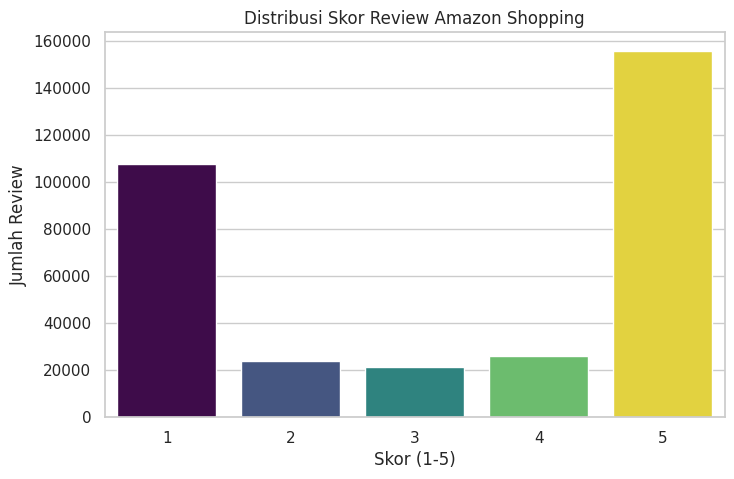

In [19]:
# 1. Distribusi Skor Review
print("\nDistribusi Skor Review:")
score_counts = df_reviews['score'].value_counts().sort_index()
print(score_counts)
print(f"Persentase per skor:\n{(score_counts / len(df_reviews) * 100).round(2)}%")

plt.figure(figsize=(8, 5))
sns.countplot(data=df_reviews, x='score', hue='score', palette='viridis', legend=False)
plt.title('Distribusi Skor Review Amazon Shopping')
plt.xlabel('Skor (1-5)')
plt.ylabel('Jumlah Review')
plt.show()


Jumlah Review per Tahun:
year
2014      760
2015    14749
2016    16988
2017    21684
2018    19139
2019    30648
2020    37297
2021    62662
2022    40001
2023    31662
2024    28346
2025    25325
2026     5540
dtype: int64


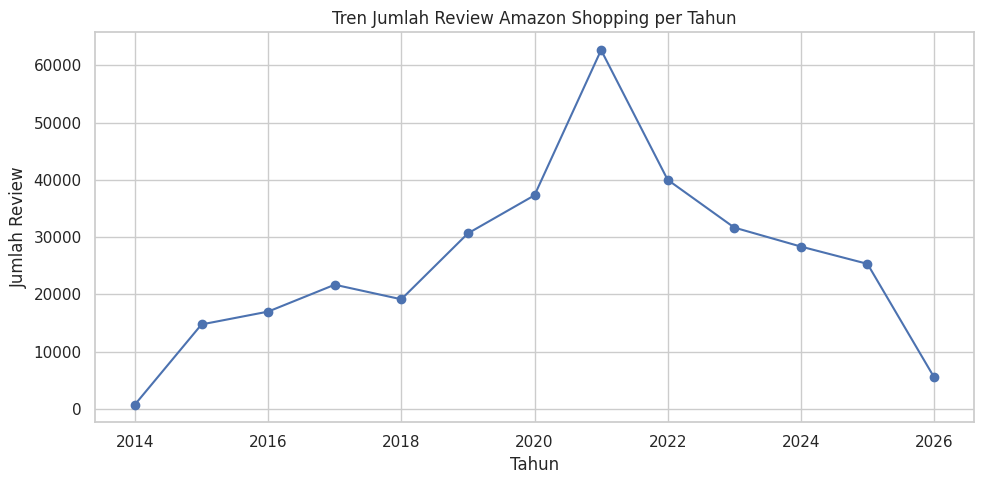

In [20]:
# 2. Tren Review Berdasarkan Waktu
df_reviews['at'] = pd.to_datetime(df_reviews['at'], errors='coerce')
df_reviews = df_reviews.dropna(subset=['at'])
df_reviews['year'] = df_reviews['at'].dt.year

print("\nJumlah Review per Tahun:")
review_trend = df_reviews.groupby('year').size()
print(review_trend)

plt.figure(figsize=(10, 5))
review_trend.plot(kind='line', marker='o')
plt.title('Tren Jumlah Review Amazon Shopping per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

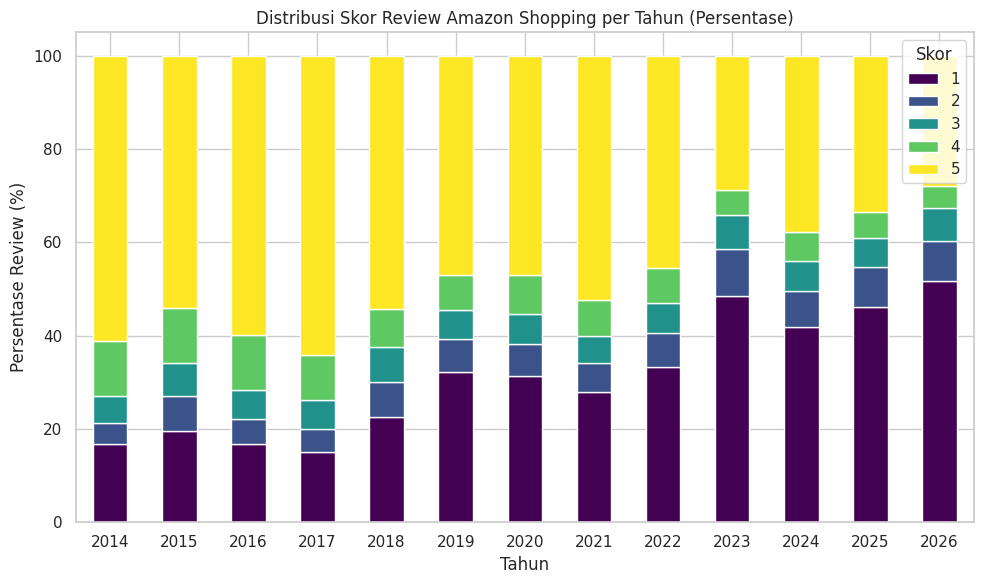

In [21]:
# 3. Distribusi Skor Review per Tahun (Stacked Bar Plot)
score_per_year = df_reviews.groupby(['year', 'score']).size().unstack(fill_value=0)
score_per_year = score_per_year.div(score_per_year.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
score_per_year.plot(kind='bar', stacked=True, cmap='viridis')
plt.title('Distribusi Skor Review Amazon Shopping per Tahun (Persentase)')
plt.xlabel('Tahun')
plt.ylabel('Persentase Review (%)')
plt.legend(title='Skor', labels=['1', '2', '3', '4', '5'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Statistik Panjang Review (Jumlah Kata):
count    334801.000000
mean         20.217281
std          22.496887
min           1.000000
25%           5.000000
50%          11.000000
75%          27.000000
max         780.000000
Name: review_length, dtype: float64


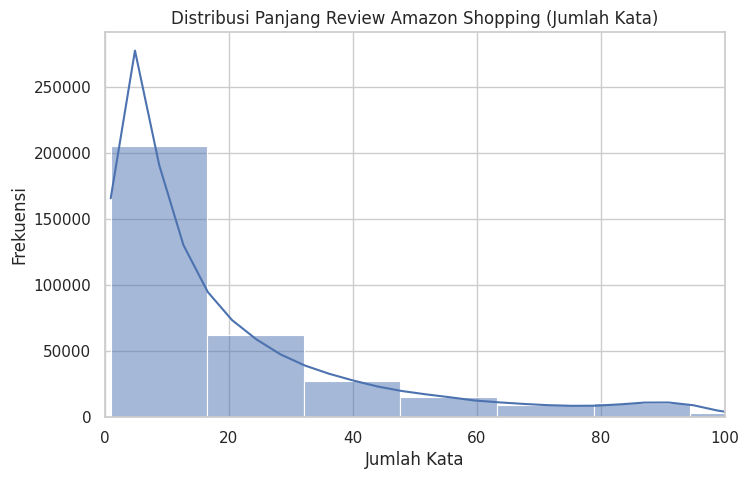

In [22]:
# 4. Panjang Review
df_reviews['review_length'] = df_reviews['content'].astype(str).apply(lambda x: len(x.split()))

print("\nStatistik Panjang Review (Jumlah Kata):")
print(df_reviews['review_length'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(data=df_reviews, x='review_length', bins=50, kde=True)
plt.title('Distribusi Panjang Review Amazon Shopping (Jumlah Kata)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 100)
plt.show()

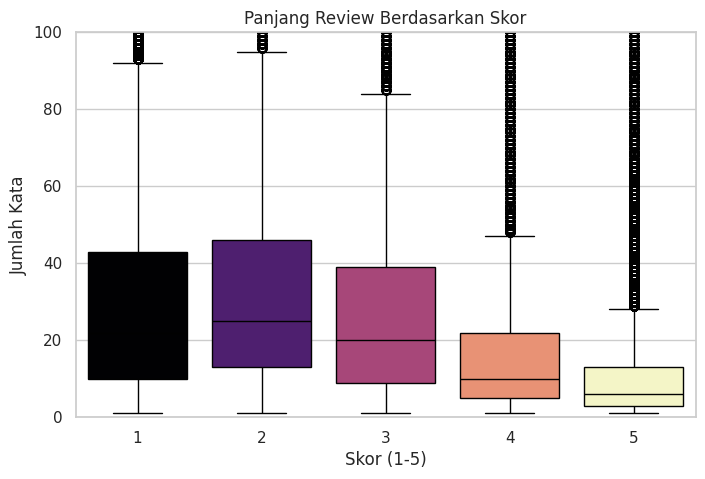

In [23]:
# 5. Korelasi antara Panjang Review dan Skor
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_reviews, x='score', y='review_length', hue='score', palette='magma', legend=False)
plt.title('Panjang Review Berdasarkan Skor')
plt.xlabel('Skor (1-5)')
plt.ylabel('Jumlah Kata')
plt.ylim(0, 100)
plt.show()

In [29]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True


20 Kata Paling Umum dalam Review:
[('i', 257323), ('the', 231463), ('to', 227633), ('it', 178905), ('and', 175584), ('app', 117114), ('a', 115056), ('is', 100304), ('amazon', 97342), ('my', 94317), ('for', 82789), ('you', 74430), ('this', 67306), ('of', 67108), ('on', 66422), ('not', 57039), ('have', 55645), ('in', 53596), ('they', 49718), ('that', 48455)]


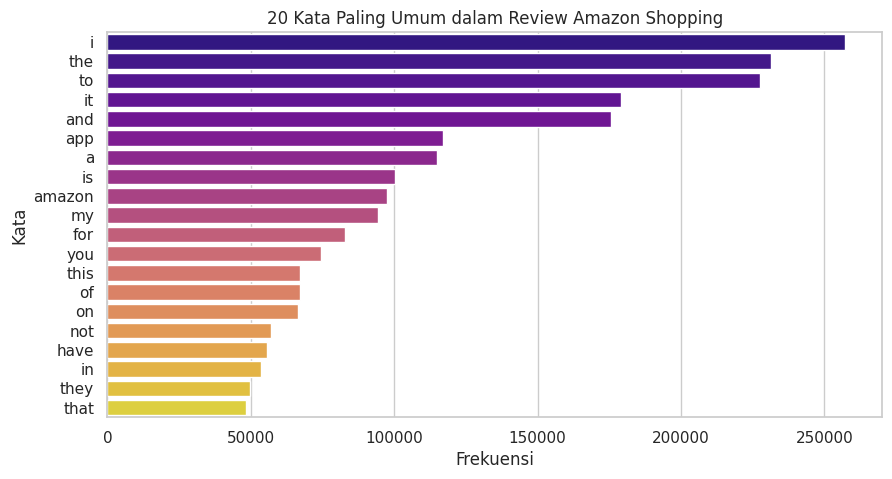

In [30]:
# 6. Kata-kata Umum dalam Review
def clean_text(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalpha()]

all_words = []
df_reviews['content'].astype(str).apply(lambda x: all_words.extend(clean_text(x)))

word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

print("\n20 Kata Paling Umum dalam Review:")
print(common_words)

plt.figure(figsize=(10, 5))
words, counts = zip(*common_words)
sns.barplot(x=counts, y=words, hue=words, palette='plasma', legend=False)
plt.title('20 Kata Paling Umum dalam Review Amazon Shopping')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

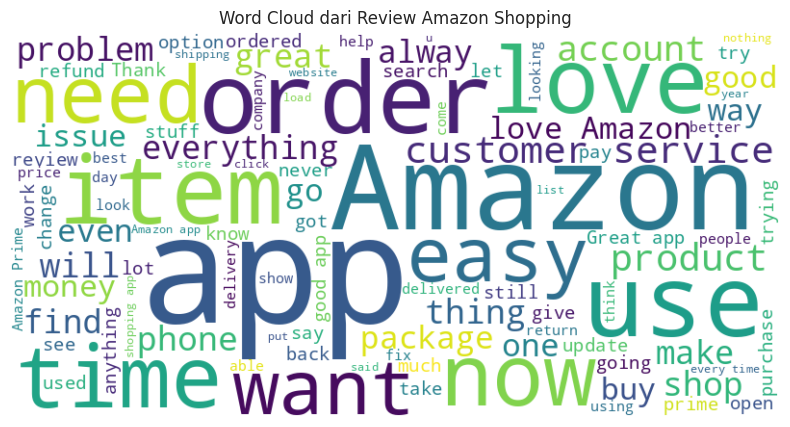

In [31]:
# 7. Word Cloud
text = ' '.join(df_reviews['content'].astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Review Amazon Shopping')
plt.show()


Jumlah Review per Versi Aplikasi (10 Versi Teratas):
reviewCreatedVersion
22.5.0.100     7428
22.6.0.100     6871
22.4.0.100     5411
22.7.0.100     4925
18.21.2.100    4202
22.11.0.100    3879
26.21.0.100    3737
22.9.0.100     3542
24.7.0.100     3128
24.12.6.100    2939
Name: count, dtype: int64


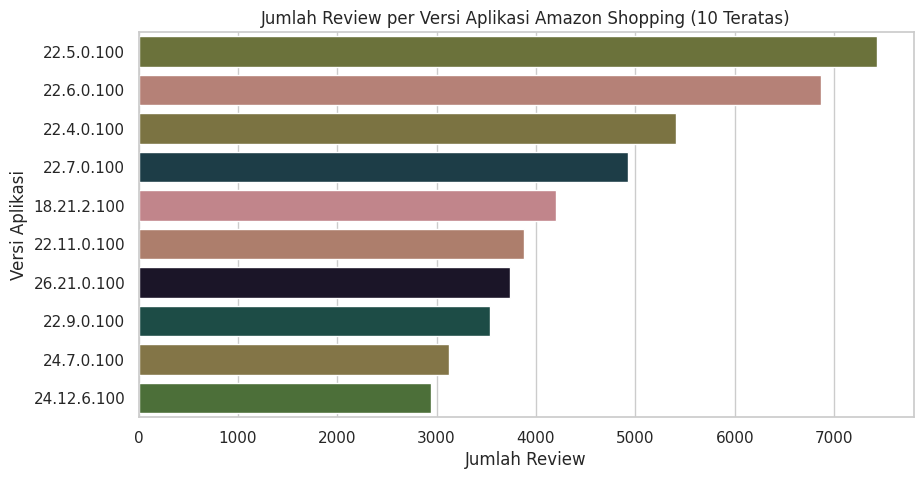

In [32]:
# 8. Analisis Versi Aplikasi
if 'reviewCreatedVersion' in df_reviews.columns:
    print("\nJumlah Review per Versi Aplikasi (10 Versi Teratas):")
    version_counts = df_reviews['reviewCreatedVersion'].value_counts().head(10)
    print(version_counts)

    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df_reviews,
        y='reviewCreatedVersion',
        hue='reviewCreatedVersion',
        order=version_counts.index,
        palette='cubehelix',
        legend=False
    )
    plt.title('Jumlah Review per Versi Aplikasi Amazon Shopping (10 Teratas)')
    plt.xlabel('Jumlah Review')
    plt.ylabel('Versi Aplikasi')
    plt.show()

In [33]:
# 9. Analisis Review yang Dibalas
if 'replyContent' in df_reviews.columns:
    print("\nJumlah Review yang Dibalas oleh Pengembang:")
    reply_counts = df_reviews['replyContent'].notnull().sum()
    print(f"{reply_counts} review memiliki balasan dari pengembang.")
    if reply_counts > 0:
        print("\nContoh review yang dibalas:")
        display(df_reviews[df_reviews['replyContent'].notnull()][['content', 'score', 'replyContent']].head())


Jumlah Review yang Dibalas oleh Pengembang:
55 review memiliki balasan dari pengembang.

Contoh review yang dibalas:


,content,score,replyContent
75633,I really hate that the search bar is now at th...,2,Sorry for your trouble. On the device experien...
86289,Always something with Amazon. Now I can't look...,1,Sorry for your trouble. On the device experien...
220326,Why do you try and have me sign up for prime m...,4,Sorry for your trouble. On the device experien...
256197,Love the app but when is it going to get finge...,4,Sorry for your trouble. On the device experien...
274905,"Current version doesn't open, even after devic...",1,Sorry for your trouble. On the device experien...
